In [1]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load data saved from preprocessing notebook
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")
y_train = pd.read_csv("../data/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/y_test.csv").values.ravel()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (40000, 14)
Testing data shape: (10000, 14)


In [3]:
# Models selected for comparison based on flood prediction research paper approach
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

In [4]:
# Store model results
results = []

# Train each model and calculate accuracy
for model_name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy
    })
    
    print("=" * 50)
    print(model_name)
    print("Accuracy:", round(accuracy, 4))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Logistic Regression
Accuracy: 0.9874

Confusion Matrix:
[[4938   62]
 [  64 4936]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5000
           1       0.99      0.99      0.99      5000

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

Decision Tree
Accuracy: 0.7778

Confusion Matrix:
[[3885 1115]
 [1107 3893]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78      5000
           1       0.78      0.78      0.78      5000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000

Random Forest
Accuracy: 0.9104

Confusion Matrix:
[[4566  434]
 [ 462 4538]]

Classification Report:
              precision    recall  f1

In [5]:
# Convert results into DataFrame
results_df = pd.DataFrame(results)

# Sort by highest accuracy
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Model,Accuracy
0,Logistic Regression,0.9874
4,SVM,0.9824
3,Gradient Boosting,0.9237
2,Random Forest,0.9104
1,Decision Tree,0.7778


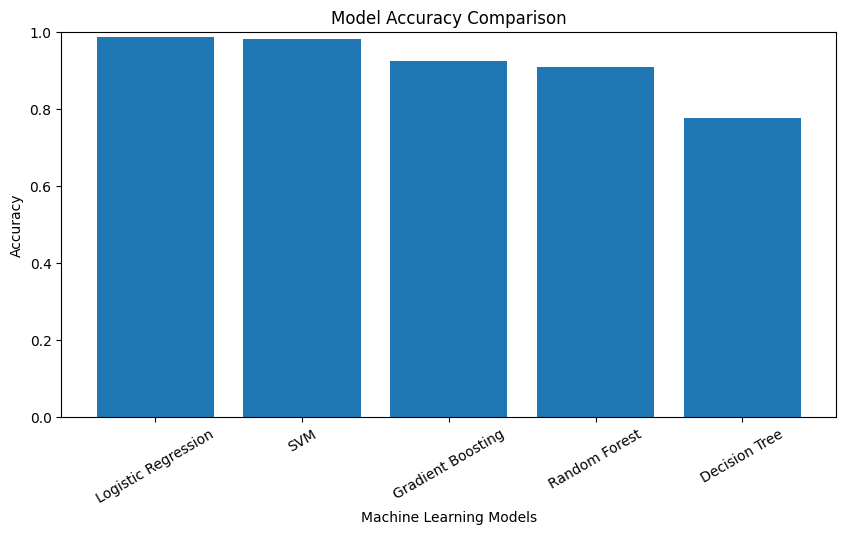

In [6]:
plt.figure(figsize=(10, 5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.show()

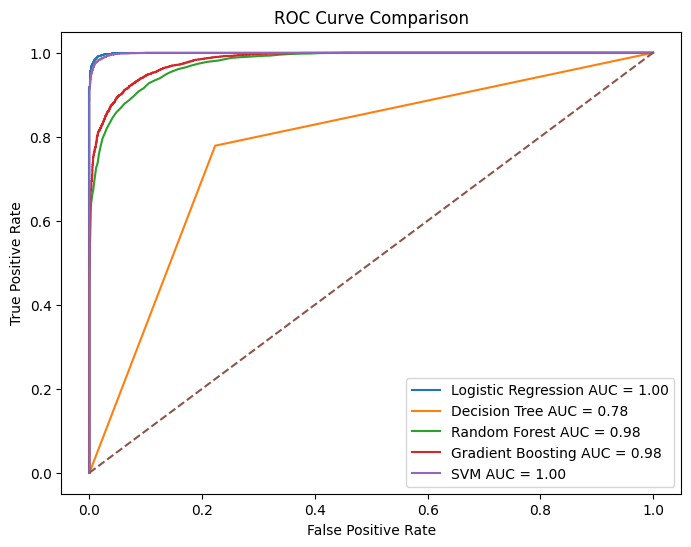

In [7]:
plt.figure(figsize=(8, 6))

# Plot ROC curve for each model
for model_name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{model_name} AUC = {roc_auc:.2f}")

# Random guess line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [8]:
best_model_name = results_df.iloc[0]["Model"]
best_accuracy = results_df.iloc[0]["Accuracy"]

print("Best Model:", best_model_name)
print("Best Accuracy:", round(best_accuracy, 4))

Best Model: Logistic Regression
Best Accuracy: 0.9874


In [9]:
print("""
Model Comparison Interpretation:

Different machine learning models were trained and evaluated for flood risk classification.
The models were compared using accuracy, confusion matrix, classification report, ROC curve, and AUC score.

The best-performing model from this comparison will be selected for further implementation from scratch.
This follows the research-based approach of comparing multiple models before selecting the final model.
""")


Model Comparison Interpretation:

Different machine learning models were trained and evaluated for flood risk classification.
The models were compared using accuracy, confusion matrix, classification report, ROC curve, and AUC score.

The best-performing model from this comparison will be selected for further implementation from scratch.
This follows the research-based approach of comparing multiple models before selecting the final model.



In [10]:
### Model Comparison Summary

### In this notebook, multiple machine learning models were compared for flood risk prediction.  
### The models included Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and SVM.

## Evaluation was done using:
## - Accuracy
## - Confusion Matrix
## - Classification Report
## - ROC Curve
## - AUC Score

## After comparing model performance, the most suitable model will be selected and implemented from scratch in the next notebook.